### Ejercicio 1: Funciones base de Bernstein

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Agregamos pandas para armar tablas

In [ ]:
def bernstein3(t):
    res = np.zeros((4, len(t)))
    for i in range(len(t)):
        ti = t[i]
        res[0][i] = (1-ti)**3
        res[1][i] = 3*((1-ti)**2)*ti
        res[2][i] = 3*(1-ti)*(ti**2)
        res[3][i] = ti**3
    return res

In [ ]:
t = np.arange(0.0, 1.01, 0.01)
datos = bernstein3(t)

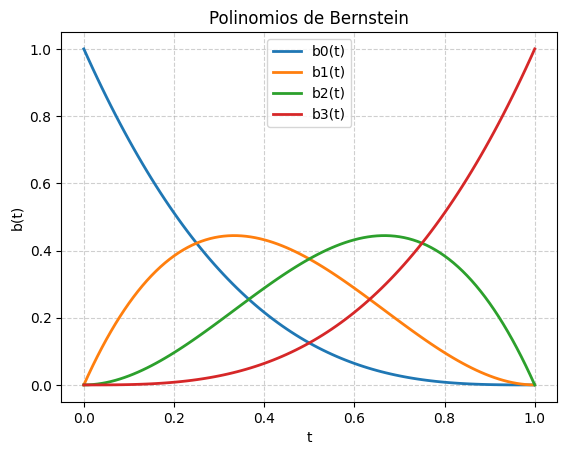

In [ ]:
def graficar_berntein(datos, etiqueta):
    x_acumulado = np.linspace(0, 1, len(datos))

    plt.plot(x_acumulado, datos, label=etiqueta, linewidth=2)

for i in range(len(datos)):
    graficar_berntein(datos[i], "b" + str(i) + "(t)")

plt.title('Polinomios de Bernstein')
plt.xlabel('t')
plt.ylabel('b(t)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.show()

### Ejercicio 2: Evaluación matricial de una curva de Bézier

In [ ]:
t = np.arange(0.0, 1.0, 0.01) # m = 100 valores equiespaciados de t
A = bernstein3(t) # A de 4x100
A = A.T # A de 100x4

In [ ]:
# Creamos la matriz con los puntos de control
PReal = np.array([[0,0],[1,3],[4,3],[5,0]]) # 4x2

In [ ]:
# Calculamos el producto matricial
CReal = A @ PReal # 100 x

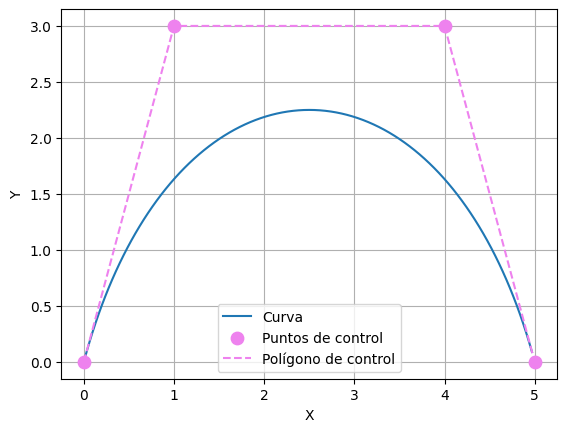

In [ ]:
# Graficamos la curva, los puntos de control y el polígono de control
plt.plot(CReal[:, 0], CReal[:, 1], label="Curva")
plt.scatter(PReal[:, 0], PReal[:, 1], color="violet", zorder=5, s=80, label="Puntos de control")
plt.plot(PReal[:, 0], PReal[:, 1], linestyle="--", color="violet", zorder=4, label="Polígono de control")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 3: Generación de datos con ruido

In [ ]:
t30 = np.linspace(0.0, 1.0, 30)
A = bernstein3(t30)
A = A.T

In [ ]:
CReal = A @ PReal

In [ ]:
rng = np.random.default_rng(seed=10)

# Generar el vector aleatorio usando el objeto 'rng'
eta = rng.normal(loc=0, scale=0.05, size=(30, 2))

In [ ]:
Q = CReal + eta

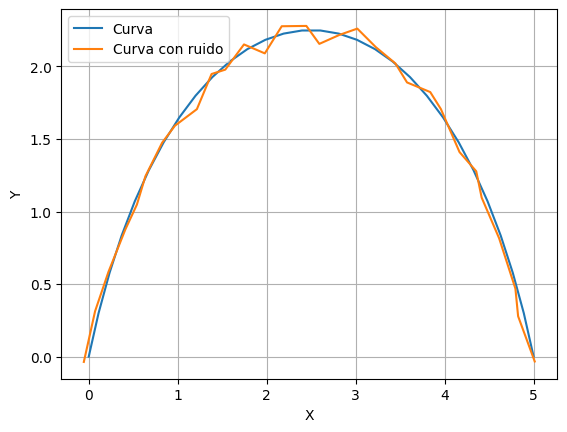

In [ ]:
# Graficamos la curva original y la de ruido
plt.plot(CReal[:, 0], CReal[:, 1], label="Curva")
plt.plot(Q[:, 0], Q[:, 1], label="Curva con ruido")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

### Ej4: Ajuste minimos cuadrados

In [ ]:
P_hat = np.linalg.inv(A.T @ A) @ A.T @ Q

In [ ]:
Q_hat = A @ P_hat

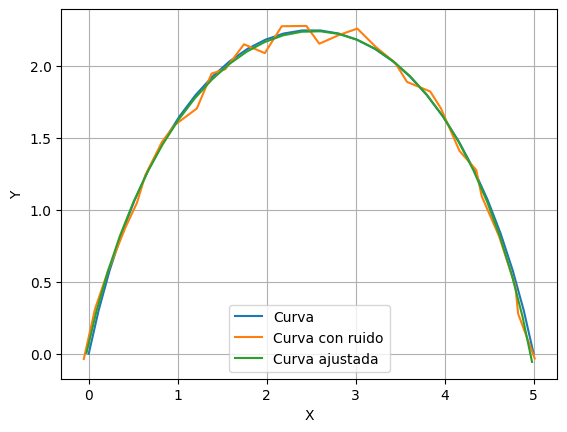

In [ ]:
# Graficamos la curva original y la de ruido
plt.plot(CReal[:, 0], CReal[:, 1], label="Curva")
plt.plot(Q[:, 0], Q[:, 1], label="Curva con ruido")
plt.plot(Q_hat[:, 0], Q_hat[:, 1], label="Curva ajustada")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def ajustar_curva_con_ruido(C, A, sigma):
  rng = np.random.default_rng(seed=10)

  # Generar el vector aleatorio usando el objeto 'rng'
  eta = rng.normal(loc=0, scale=sigma, size=(30, 2))
  Q = C + eta
  P_hat = np.linalg.inv(A.T @ A) @ A.T @ Q
  return P_hat

In [ ]:
def calcular_ecm(Q, Q_hat):
  ecm = 0
  for i in range(30):
    [x,y] = (Q[i] - Q_hat[i])
    ecm += x**2 + y**2
  return ecm / 30

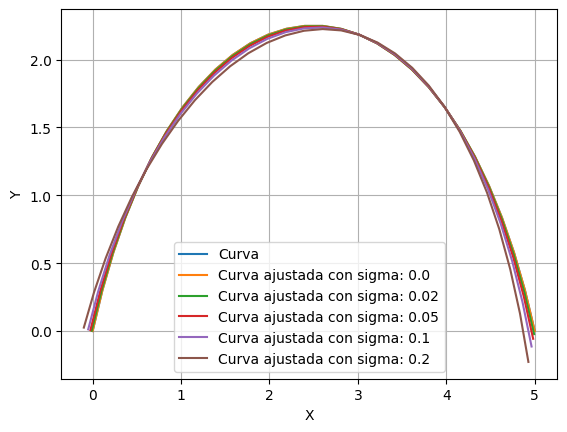

In [ ]:
sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]
plt.plot(CReal[:, 0], CReal[:, 1], label="Curva")

ECM = []
puntos_de_control = []

for sigma in sigmas:
  P_hat_i = ajustar_curva_con_ruido(CReal, A, sigma)
  Q_hat_i = A @ P_hat_i
  plt.plot(Q_hat_i[:, 0], Q_hat_i[:, 1], label={"Curva ajustada con sigma: " + str(sigma)})
  ECM.append([sigma, calcular_ecm(CReal, Q_hat_i)])
  puntos_de_control.append(P_hat_i)


plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
tabla = pd.DataFrame(ECM)
tabla.columns = ['sigma', 'error']
tabla

,sigma,error
0,0.00,2.158857e-30
1,0.02,8.377830e-05
2,0.05,5.236144e-04
3,0.10,2.094458e-03
4,0.20,8.377830e-03


### Ej5: La funcion de error como forma cuadratica

In [ ]:
sim = A.T @ A
np.linalg.eig(sim) # Todos autovalores positivos, está definida positiva

EigResult(eigenvalues=array([7.51154315, 4.8161144 , 1.70568592, 0.25824389]), eigenvectors=array([[ 0.52179727,  0.67835134,  0.47720814, -0.19959826],
       [ 0.47720814,  0.19959826, -0.52179727,  0.67835134],
       [ 0.47720814, -0.19959826, -0.52179727, -0.67835134],
       [ 0.52179727, -0.67835134,  0.47720814,  0.19959826]]))

### EJ6: Ecuaciones normales a partir del gradiente

In [ ]:
def gradiente(p, A, q):
  return 2 * A.T @ (A@p - q)

In [ ]:
p = np.array([0,0,0,0])
gradiente(p, A, Q_hat[:, 0])

array([-12.57935231, -28.06846078, -44.19711998, -64.65658302])

In [ ]:
gradiente(P_hat[:, 0], A, Q_hat[:, 0])

array([-1.53043167e-17, -2.62203642e-16, -4.86305817e-16,  4.30746868e-16])

###EJ7: Gradiente descendiente para ajustar una curva

In [ ]:
alpha = 0.01
k = 1000

In [ ]:
p_0 = np.random.randint(-100, 101, 4)
p_1 = np.random.randint(-100, 101, 4)
gradiente(p_0, A, Q_hat[:, 0])

array([-249.98322978,   72.88071725,  523.51285161, 1041.32952415])

In [ ]:
def actualizar(p_0, A, q, alpha):
  return p_0 - alpha * gradiente(p_0, A, q)

In [ ]:
def E(p, A, q):
  return ((A @ p) - q) @ ((A @ p) - q)

In [ ]:
errores = []
for i in range(k):
  p_0 = actualizar(p_0, A, Q[:, 0], alpha)
  p_1 = actualizar(p_1, A, Q[:, 1], alpha)
  errores.append([i, E(p_0, A, Q[:, 0])])
  if i % 100 == 0:
    print("Iteracion: " + str(i) + " - mínimo hasta el momento: " + str(gradiente(p_0, A, Q[:, 0])))

Iteracion: 0 - mínimo hasta el momento: [-242.68053424   42.79507373  455.95058461  922.50538349]
Iteracion: 100 - mínimo hasta el momento: [  6.60055994 -20.32511775  18.24312382  -4.69638191]
Iteracion: 200 - mínimo hasta el momento: [  3.40912594 -11.51797412  11.45324655  -3.34992954]
Iteracion: 300 - mínimo hasta el momento: [ 2.01449179 -6.84429722  6.84228493 -2.01265146]
Iteracion: 400 - mínimo hasta el momento: [ 1.19974344 -4.07736217  4.07729962 -1.19968622]
Iteracion: 500 - mínimo hasta el momento: [ 0.71480818 -2.42933315  2.42933121 -0.7148064 ]
Iteracion: 600 - mínimo hasta el momento: [ 0.42589245 -1.44743096  1.4474309  -0.4258924 ]
Iteracion: 700 - mínimo hasta el momento: [ 0.25375281 -0.86240009  0.86240009 -0.25375281]
Iteracion: 800 - mínimo hasta el momento: [ 0.15118956 -0.51383033  0.51383033 -0.15118956]
Iteracion: 900 - mínimo hasta el momento: [ 0.09008091 -0.30614748  0.30614748 -0.09008091]


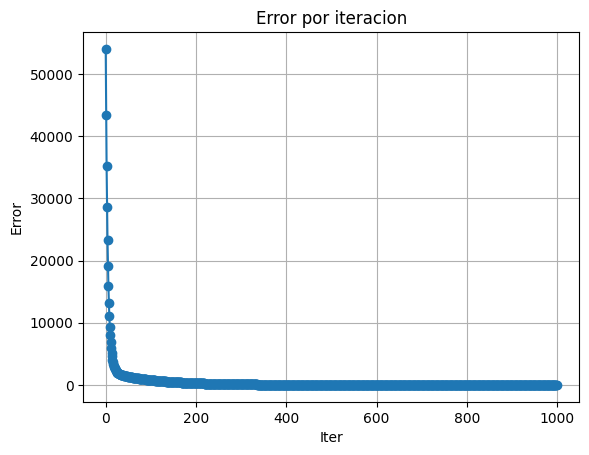

In [ ]:
x = [e[0] for e in errores]
y = [e[1] for e in errores]

plt.plot(x, y, marker='o')
plt.xlabel("Iter")
plt.ylabel("Error")
plt.title("Error por iteracion")
plt.grid(True)
plt.show()

In [ ]:
# Error en x por gradiente descendiente
E(p_0, A, Q[:, 0])

np.float64(0.10015336105254072)

In [ ]:
# Error en x por minimos cuadrados
E(P_hat[:, 0], A, Q[:, 0])

np.float64(0.02942694882923816)

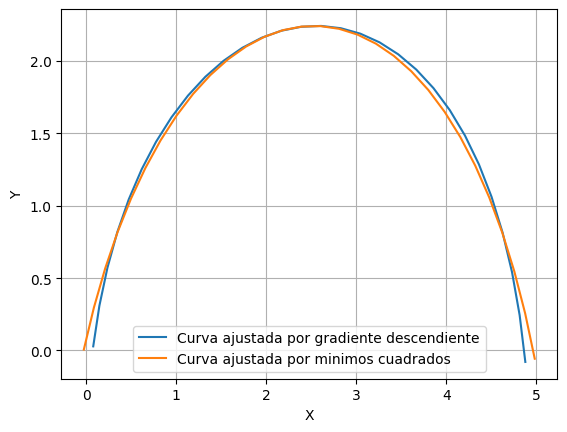

In [ ]:
P_gradiente = np.column_stack((p_0, p_1))
Q_gradiente = A @ P_gradiente

# Graficamos la curva de minimos cuadrados y la de gradiente descendiente
plt.plot(Q_gradiente[:, 0], Q_gradiente[:, 1], label="Curva ajustada por gradiente descendiente")
plt.plot(Q_hat[:, 0], Q_hat[:, 1], label="Curva ajustada por minimos cuadrados")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 8: Efecto de la tasa de aprendizaje

In [ ]:
def ajustar_x_por_gradiente_descendiente(p_x, q_x, alpha, k):
  for i in range(k):
    p_x = actualizar(p_x, A, q_x, alpha)
  return p_x

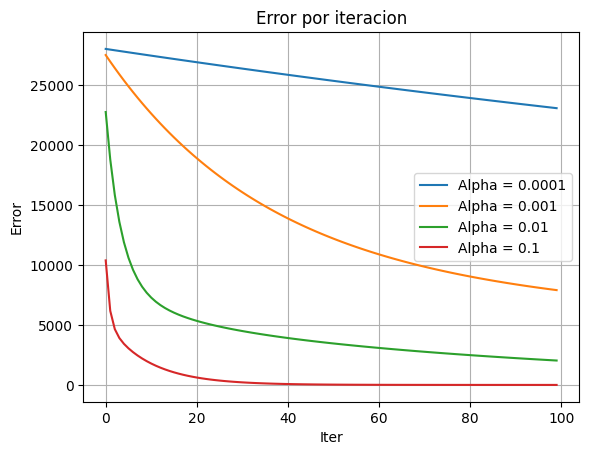

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1]
k = 100
p_x = np.random.randint(-100, 101, 4)
p_x_i = p_x.copy()
for alpha in alphas:
  errores = []
  for i in range(k):
    p_x_i = actualizar(p_x_i, A, Q_hat[:, 0], alpha)
    errores.append([i, E(p_x_i, A, Q_hat[:, 0])])
  x = [e[0] for e in errores]
  y = [e[1] for e in errores]
  plt.plot(x, y, label={"Alpha = " + str(alpha)})
  p_x_i = p_x.copy()


plt.xlabel("Iter")
plt.ylabel("Error")
plt.title("Error por iteracion")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 9: Metodo de Newton para el mismo problema

In [ ]:
def actualizar_newton(p_t, A, q, HESSIANO):
  return p_t - np.linalg.inv(HESSIANO) @ gradiente(p_0, A, q)

In [ ]:
HESSIANO = 2 * (A.T @ A)

In [ ]:
p_0 = np.random.randint(-100, 101, 4)
p_1x = actualizar_newton(p_0, A, Q[:, 0], HESSIANO) # DA IGUAL A MINIMOS CUADRADOS
p_1y = actualizar_newton(p_0, A, Q[:, 1], HESSIANO)

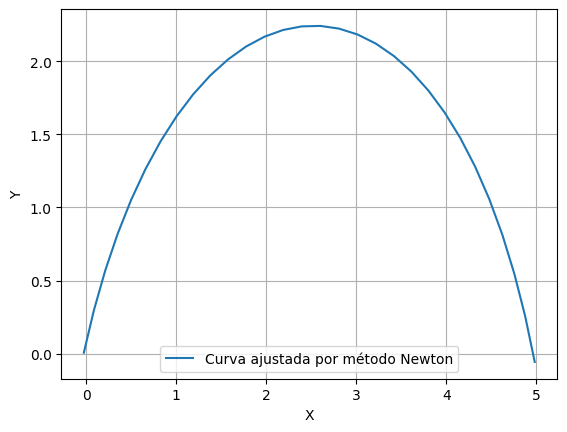

In [ ]:
P_newton = np.column_stack((p_1x, p_1y))
Q_newton = A @ P_newton

# Graficamos la curva de minimos cuadrados y la de gradiente descendiente
plt.plot(Q_newton[:, 0], Q_newton[:, 1], label="Curva ajustada por método Newton")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 10: Ajuste con extremos fijos

In [ ]:
Aint = np.column_stack((A[:, 1], A[:, 2]))
Aext = np.column_stack((A[:, 0], A[:, 3]))

In [ ]:
P0 = Q[0,:]
P3 = Q[29, :]

b = Q - (Aext @ np.array([P0, P3]))

In [ ]:
P_int = np.linalg.inv(Aint.T @ Aint) @ Aint.T @ b
P_ejercicio_10 = np.array([P0, P_int[0], P_int[1], P3])

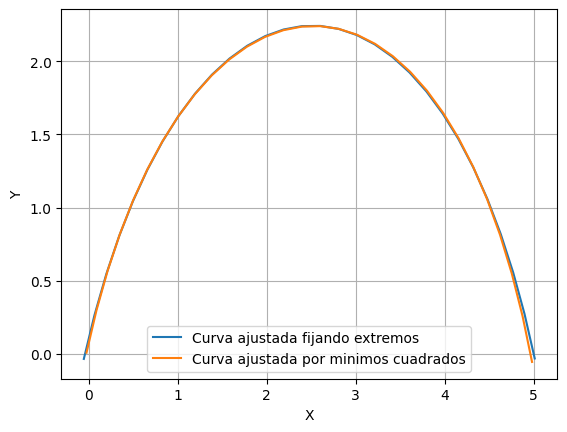

In [ ]:
Q_ejercicio_10 = A @ P_ejercicio_10

# Graficamos la curva de minimos cuadrados y la de gradiente descendiente
plt.plot(Q_ejercicio_10[:, 0], Q_ejercicio_10[:, 1], label="Curva ajustada fijando extremos")
plt.plot(Q_hat[:, 0], Q_hat[:, 1], label="Curva ajustada por minimos cuadrados")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 11: Podadora robot :)

In [ ]:
from math import comb

def bernstein(n, t):
    res = np.zeros((len(t), n + 1))

    for j in range(len(t)):
        tj = t[j]

        for k in range(n + 1):
            res[j][k] = comb(n, k) * ((1 - tj) ** (n - k)) * (tj ** k)

    return res

In [ ]:
def bezier(P, t):
  return bernstein(len(P)-1, t) @ P

In [ ]:
# Obstáculos

centros_obs = np.array([ # Centros
    [2,  1],
    [3, -2],
    [5,  0],
    [7,  2],
    [8, -2],
    [6, -2],
    [10, 1],
    [11,-2]
], dtype=float)

radios_obs = np.array([1, 1, 1.5, 1, 1, 0.5, 1.5, 1], dtype=float) # Radios

def hay_colision(B):
  # Buscar minimos
  mins = np.full(len(centros_obs), np.inf)

  for j in range(len(centros_obs)):
      obj = centros_obs[j]

      for p in B:
          dist = np.linalg.norm(p - obj)

          if dist < mins[j]:
              mins[j] = dist
  hay_colision = False
  for j in range(len(mins)):
    if mins[j] < radios_obs[j]:
      hay_colision = True
  return hay_colision

In [ ]:
t = np.linspace(0.0, 1.0, 200)

In [ ]:
O = [0,0]
D = [12, 0]

def Pk(k, n, a):
    return np.array([
        12 * k / n,
        a * np.sin(np.pi * k / n)
    ])

def puntos_control(n, a):
    pc = np.zeros((n + 1, 2))
    pc[0] = O
    for k in range(1, n):
        pc[k] = Pk(k, n, a)
    pc[n] = D
    return pc

In [ ]:
def plot_circulos(c, r):
    ax = plt.gca()  # eje actual

    for i in range(len(c)):
        circulo = plt.Circle(c[i], r[i], fill=False)
        ax.add_patch(circulo)

        ax.plot(c[i, 0], c[i, 1], 'o')

    ax.set_aspect('equal')

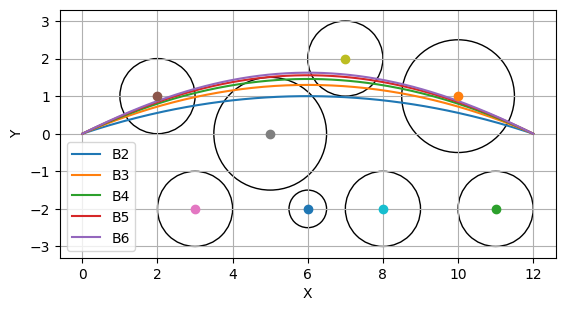

In [ ]:
ns = [2,3,4,5,6]
a = 2

Curvas = []
PCs = []

for n in ns:
  PCs.append(puntos_control(n, a))
  Bn = bezier(puntos_control(n, a), t)
  plt.plot(Bn[:, 0], Bn[:, 1], label={"B" + str(n)})
  Curvas.append(Bn)
plot_circulos(centros_obs, radios_obs)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
hay_colision(Curvas[4])

True

### Ejercicio 12: Optimización automática del grado y de la trayectoria

In [ ]:
lambdaSuav = 0.01
lambdaObs = 10
lambdaBordes = 1000
lambdas = [lambdaSuav, lambdaObs, lambdaBordes]

delta = 0.1

p0 = np.array([0,0])
pn = np.array([12,0])

In [ ]:
def pasar_a_pc(theta, p0, pn):
  pc = np.zeros((len(theta)//2 + 2, 2))
  pc[0] = p0
  for k in range(len(theta)//2):
    pc[k+1] = [theta[2*k], theta[2*k+1]]
  pc[-1] = pn
  return pc

In [ ]:
def pasar_a_theta(pc):
    return pc[1:-1].flatten()

In [ ]:
# Curva de bezier y su grado
def E_Largo(B):
  sum = 0
  for i in range(0, len(B)-1):
    sum += np.linalg.norm(B[i+1]-B[i])**2
  return sum

In [ ]:
def E_Smooth(theta, p0, pn):
  P = pasar_a_pc(theta, p0, pn)

  sum = 0
  for i in range(1, len(P)-1):
    sum += np.linalg.norm(P[i-1] - 2*P[i] + P[i+1])**2
  return sum

In [ ]:
def E_Obst(B, p0, pn, delta):
  sum = 0
  for i in range(2, len(B)-2):
    for j in range(len(centros_obs)): # por cada obstaculo
      sum += max(0, radios_obs[j]+delta - np.linalg.norm(B[i] - centros_obs[j]))**2
  return sum

In [ ]:
def E_Bordes(B): # Que no se escape
    costo = 0

    for p in B:
        x, y = p

        costo += max(0, y - 3)**2
        costo += max(0, -3 - y)**2
        costo += max(0, x - 13)**2

    return costo

In [ ]:
def costo(theta, lambdas):
    B = bezier(pasar_a_pc(theta, p0, pn), t)
    lambdaSuav, lambdaObs, lambdaBordes = lambdas
    return (
        E_Largo(B)
        + lambdaSuav * E_Smooth(theta, p0, pn)
        + lambdaObs * E_Obst(B, p0, pn, delta)
        + lambdaBordes * E_Bordes(B)
    )

In [ ]:
def gradiente_error(theta, eps, lambdas):
  grad = np.zeros_like(theta, dtype=float)

  for k in range(len(theta)):
      theta_mas= theta.copy()
      theta_menos = theta.copy()

      theta_mas[k] += eps
      theta_menos[k] -= eps

      grad[k] = (
          costo(theta_mas, lambdas) - costo(theta_menos, lambdas)
      ) / (2 * eps)

  return grad

In [ ]:
def actualizar(theta, alpha, eps, lambdas):
  return theta - alpha * gradiente_error(theta, eps, lambdas)

In [ ]:
alpha = 0.01
eps = 1
k = 100

OPTIMIZADOS = []
ERRORES = []
contador = 2
for pc in PCs:
  ERROR_PC= []
  theta = pasar_a_theta(pc)
  for i in range(k):
    costo_i= costo(theta, lambdas)
    ERROR_PC.append(costo_i)
    theta = actualizar(theta, alpha, eps, lambdas)
    if i % 50 == 0:
      print("-- Iter ", i, " de n=",contador)
  OPTIMIZADOS.append(theta)
  ERRORES.append(ERROR_PC)

  contador+=1

-- Iter  0  de n= 2
-- Iter  50  de n= 2
-- Iter  0  de n= 3
-- Iter  50  de n= 3
-- Iter  0  de n= 4
-- Iter  50  de n= 4
-- Iter  0  de n= 5
-- Iter  50  de n= 5
-- Iter  0  de n= 6
-- Iter  50  de n= 6


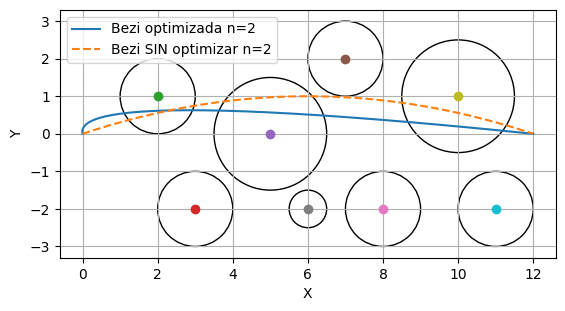

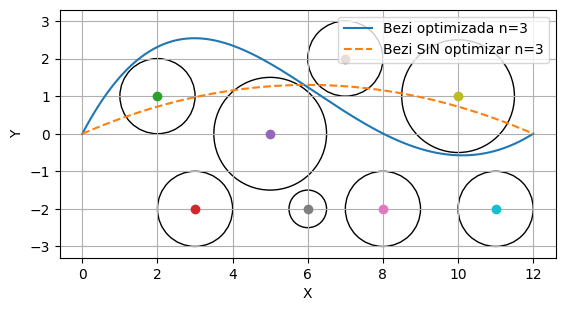

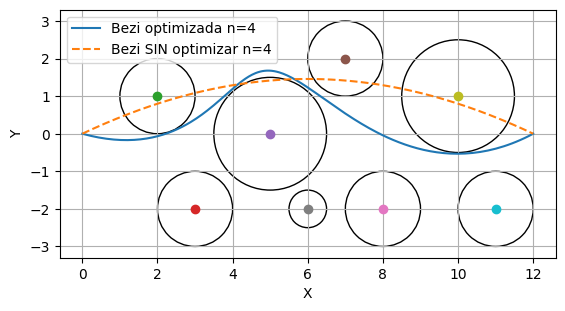

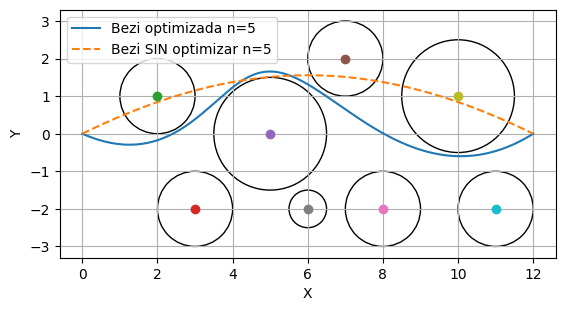

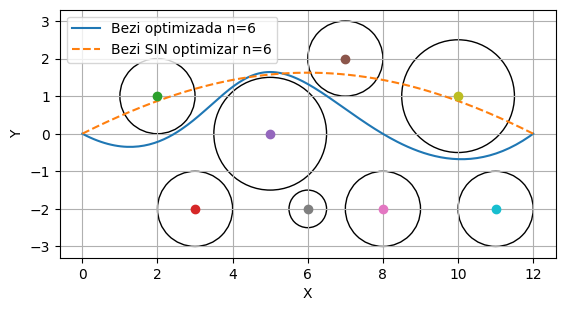

In [ ]:
for i in range(len(OPTIMIZADOS)):
  theta = OPTIMIZADOS[i]
  beziPC = pasar_a_pc(theta, p0, pn)
  bezi = bezier(beziPC, t)
  plt.plot(bezi[:, 0], bezi[:, 1], label={"Bezi optimizada n=" + str(i+2)})

  original = bezier(PCs[i],t)
  plt.plot(original[:, 0], original[:, 1], linestyle='dashed', label={"Bezi SIN optimizar n=" + str(i+2)})
  plot_circulos(centros_obs, radios_obs)
  plt.legend()
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.legend()
  plt.grid(True)
  plt.show()


In [ ]:
from matplotlib.lines import lineStyles
def plotear_lista_de_thetas(lista_de_thetas):
  for i in range(len(lista_de_thetas)):
    theta = lista_de_thetas[i]
    beziPC = pasar_a_pc(theta, p0, pn)
    bezi = bezier(beziPC, t)
    plt.plot(bezi[:, 0], bezi[:, 1], label={"Bezi n=" + str(i+2)})

    original = bezier(PCs[i],t)
    plt.plot(original[:, 0], original[:, 1], linestyle='dashed', label={"Bezi SIN optimizar n=" + str(i+2)})
    plot_circulos(centros_obs, radios_obs)
    plt.legend()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
gradiente_error(OPTIMIZADOS[-1], eps, lambdas)

array([-0.04284186,  0.01067261,  0.03202068, -0.01097654,  0.06516313,
       -0.00280573,  0.01878165,  0.11724068, -0.02687993, -0.22588606])

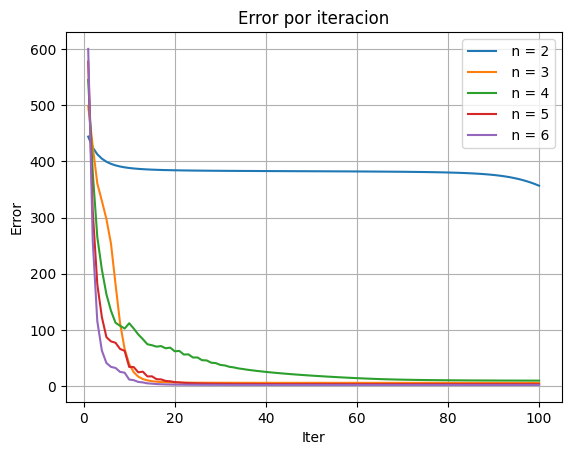

In [ ]:
for i in range(len(ERRORES)):
  error_i = ERRORES[i]
  x = np.arange(1,len(error_i) + 1)
  y = np.array(error_i)
  plt.plot(x, y, label= {" n = " + str(i+2)})

plt.xlabel("Iter")
plt.ylabel("Error")
plt.legend()
plt.title("Error por iteracion")
plt.grid(True)
plt.show()

In [ ]:
for i in range(len(OPTIMIZADOS)):
  theta = OPTIMIZADOS[i]
  beziPC = pasar_a_pc(theta, p0, pn)
  bezi = bezier(beziPC, t)

  print(hay_colision(bezi))


True
False
False
False
False


### Ejericio 13: Análisis de la trayectoria obtenida

In [ ]:
def longitud_curva (B):
  diferencias = np.diff(B, axis=0)  # vectores entre puntos consecutivos
  distancias = np.linalg.norm(diferencias, axis=1)
  return np.sum(distancias)


In [ ]:
def cantcolisiones (B):
  mins = np.full(len(centros_obs), np.inf)
  for j in range(len(centros_obs)):
    obj = centros_obs[j]
    for p in B:
      dist = np.linalg.norm(p - obj)
      if dist < mins[j]:
        mins[j] = dist
  return np.sum(mins < radios_obs)

In [ ]:
def es_factible(B, cant_colisiones):
  if cant_colisiones > 0:
    return False

  # Buscar minimos
  mins = np.full(len(centros_obs), np.inf)

  for j in range(len(centros_obs)):
      obj = centros_obs[j]

      for p in B:
          dist = np.linalg.norm(p - obj)

          if dist < mins[j]:
              mins[j] = dist
  factible = True
  for j in range(len(mins)):
    if mins[j] < radios_obs[j] + (delta - 0.5):
      factible = False
  return factible

In [ ]:
def distancia_min (B):
  minima = np.inf
  for j in range(len(centros_obs)):
    obj = centros_obs[j]
    for p in B:
      dist = np.linalg.norm(p - obj) - radios_obs[j]
      if dist < minima:
        minima = dist
  return minima

In [ ]:
resultados = []

for i in range(len(OPTIMIZADOS)):
    theta = OPTIMIZADOS[i]

    beziPC = pasar_a_pc(theta, p0, pn)
    bezi = bezier(beziPC, t)

    longitud = longitud_curva(bezi)
    colisiones = cantcolisiones(bezi)
    distancia_minima = distancia_min (bezi)
    costo_final = costo(theta, lambdas)
    factible = es_factible(bezi, colisiones)

    resultados.append({
        "Grado": i + 2,
        "Longitud": longitud,
        "Colisiones": colisiones,
        "Distancia mínima": distancia_minima,
        "Costo final": costo_final,
        "Factible": factible,
    })

tabla = pd.DataFrame(resultados)
tabla

,Grado,Longitud,Colisiones,Distancia mínima,Costo final,Factible
0,2,12.271900,3,-0.931258,353.207532,False
1,3,14.017504,0,0.072410,5.678041,True
2,4,13.205795,0,0.016113,9.697904,True
3,5,13.311897,0,0.073514,3.362696,True
4,6,13.411219,0,0.087234,2.050800,True


In [ ]:
def imprimir_tabla(lista_thetas):
  resultados = []
  for i in range(len(lista_thetas)):
      theta = lista_thetas[i]

      beziPC = pasar_a_pc(theta, p0, pn)
      bezi = bezier(beziPC, t)

      longitud = longitud_curva(bezi)
      colisiones = cantcolisiones(bezi)
      distancia_minima = distancia_min (bezi)
      costo_final = costo(theta, lambdas)
      factible = es_factible(bezi, colisiones)

      resultados.append({
          "Grado": i + 2,
          "Longitud": longitud,
          "Colisiones": colisiones,
          "Distancia mínima": distancia_minima,
          "Costo final": costo_final,
          "Factible": factible,
      })

  tabla = pd.DataFrame(resultados)
  print(tabla)

#### Cambiar lambdaObs

In [ ]:
alpha = 0.01
eps = 0.000001
k = 50
delta = 0.2
lambdaObss = [1,10,100]
Lista_De_Optimizados = []
for lambdaObs in lambdaObss:
  lambdas = [lambdaSuav, lambdaObs, lambdaBordes]
  optimizados = []
  contador = 2
  for pc in PCs:
    ERROR_PC= []
    theta = pasar_a_theta(pc)
    for i in range(k):
      costo_i= costo(theta, lambdas)
      ERROR_PC.append(costo_i)
      theta = actualizar(theta, alpha, eps, lambdas)
      if i % 50 == 0:
        print("-- lambdaObs:", str(lambdaObs),"Iter", i, "de n=",contador)
    optimizados.append(theta)
    contador+=1
  Lista_De_Optimizados.append(optimizados)

-- lambdaObs: 1 Iter 0 de n= 2
-- lambdaObs: 1 Iter 0 de n= 3
-- lambdaObs: 1 Iter 0 de n= 4
-- lambdaObs: 1 Iter 0 de n= 5
-- lambdaObs: 1 Iter 0 de n= 6
-- lambdaObs: 10 Iter 0 de n= 2
-- lambdaObs: 10 Iter 0 de n= 3
-- lambdaObs: 10 Iter 0 de n= 4
-- lambdaObs: 10 Iter 0 de n= 5
-- lambdaObs: 10 Iter 0 de n= 6
-- lambdaObs: 100 Iter 0 de n= 2
-- lambdaObs: 100 Iter 0 de n= 3
-- lambdaObs: 100 Iter 0 de n= 4
-- lambdaObs: 100 Iter 0 de n= 5
-- lambdaObs: 100 Iter 0 de n= 6


In [ ]:
for theta_optimizado in Lista_De_Optimizados:
   imprimir_tabla(theta_optimizado)

   Grado   Longitud  Colisiones  Distancia mínima  Costo final  Factible
0      2  12.192926           3         -0.942741  5301.202298     False
1      3  12.722655           3         -0.717649  2308.212533     False
2      4  12.658558           3         -0.712080  1475.403530     False
3      5  12.841718           2         -0.381367   764.905291     False
4      6  13.047178           3         -0.201971   419.097057     False
   Grado   Longitud  Colisiones  Distancia mínima  Costo final  Factible
0      2  12.184532           3         -0.802830  5117.358995     False
1      3  14.346632           0          0.146321    10.892650      True
2      4  13.461559           1         -0.317520   322.808884     False
3      5  13.768284           0          0.147154     9.933713      True
4      6  13.907086           0          0.147757     6.114564      True
   Grado      Longitud  Colisiones  Distancia mínima   Costo final  Factible
0      2  4.186254e+10           0          0.7

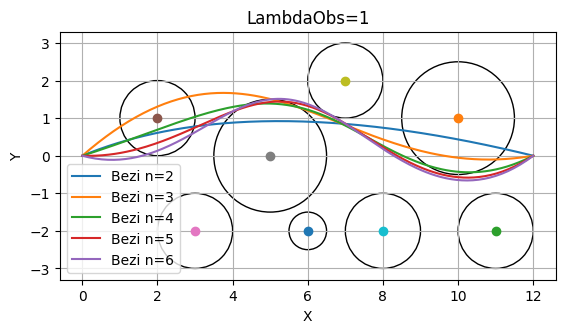

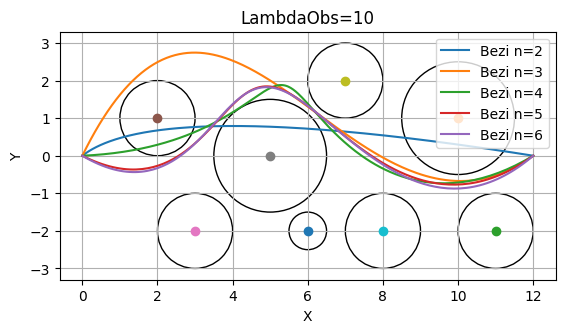

In [ ]:
def plotear_lista_en_un_plot(lista_de_thetas, label):
  for i in range(len(lista_de_thetas)):
    theta = lista_de_thetas[i]
    beziPC = pasar_a_pc(theta, p0, pn)
    bezi = bezier(beziPC, t)
    plt.plot(bezi[:, 0], bezi[:, 1], label={"Bezi n=" + str(i+2)})

  plot_circulos(centros_obs, radios_obs)
  plt.legend()
  plt.title(label)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.legend()
  plt.grid(True)
  plt.show()

for i in range(len(Lista_De_Optimizados)-1):
  plotear_lista_en_un_plot(Lista_De_Optimizados[i], "LambdaObs="+str(lambdaObss[i]))

#### Cambiar lambdaSmooth

In [ ]:
alpha = 0.01
eps = 0.000001
k = 100
delta = 0.1
lambdaObs = 10
lambdaSuavs = [0, 0.1, 1]

Lista_De_OptimizadosSmooth = []
for lambdaSuav in lambdaSuavs:
  lambdas = [lambdaSuav, lambdaObs, lambdaBordes]
  optimizados = []
  contador = 2
  for pc in PCs:
    ERROR_PC= []
    theta = pasar_a_theta(pc)
    for i in range(k):
      costo_i= costo(theta, lambdas)
      ERROR_PC.append(costo_i)
      theta = actualizar(theta, alpha, eps, lambdas)
      if i % 50 == 0:
        print("-- lambdaSuav:", str(lambdaSuav),"Iter", i, "de n=",contador)
    optimizados.append(theta)
    contador+=1
  Lista_De_OptimizadosSmooth.append(optimizados)

-- lambdaSuav: 0 Iter 0 de n= 2
-- lambdaSuav: 0 Iter 50 de n= 2
-- lambdaSuav: 0 Iter 0 de n= 3
-- lambdaSuav: 0 Iter 50 de n= 3
-- lambdaSuav: 0 Iter 0 de n= 4
-- lambdaSuav: 0 Iter 50 de n= 4
-- lambdaSuav: 0 Iter 0 de n= 5
-- lambdaSuav: 0 Iter 50 de n= 5
-- lambdaSuav: 0 Iter 0 de n= 6
-- lambdaSuav: 0 Iter 50 de n= 6
-- lambdaSuav: 0.1 Iter 0 de n= 2
-- lambdaSuav: 0.1 Iter 50 de n= 2
-- lambdaSuav: 0.1 Iter 0 de n= 3
-- lambdaSuav: 0.1 Iter 50 de n= 3
-- lambdaSuav: 0.1 Iter 0 de n= 4
-- lambdaSuav: 0.1 Iter 50 de n= 4
-- lambdaSuav: 0.1 Iter 0 de n= 5
-- lambdaSuav: 0.1 Iter 50 de n= 5
-- lambdaSuav: 0.1 Iter 0 de n= 6
-- lambdaSuav: 0.1 Iter 50 de n= 6
-- lambdaSuav: 1 Iter 0 de n= 2
-- lambdaSuav: 1 Iter 50 de n= 2
-- lambdaSuav: 1 Iter 0 de n= 3
-- lambdaSuav: 1 Iter 50 de n= 3
-- lambdaSuav: 1 Iter 0 de n= 4
-- lambdaSuav: 1 Iter 50 de n= 4
-- lambdaSuav: 1 Iter 0 de n= 5
-- lambdaSuav: 1 Iter 50 de n= 5
-- lambdaSuav: 1 Iter 0 de n= 6
-- lambdaSuav: 1 Iter 50 de n= 6


In [ ]:
for theta_optimizado in Lista_De_OptimizadosSmooth:
   imprimir_tabla(theta_optimizado)

   Grado   Longitud  Colisiones  Distancia mínima  Costo final  Factible
0      2  12.659154           3         -1.010328   568.696442     False
1      3  14.127989           0          0.093852   492.500183      True
2      4  13.302224           0          0.050761   844.355211      True
3      5  13.416942           0          0.089519   257.867956      True
4      6  13.470324           0          0.093056   114.515528      True
   Grado   Longitud  Colisiones  Distancia mínima  Costo final  Factible
0      2  12.184704           3         -0.850663   432.138422     False
1      3  13.688250           1         -0.036332   365.179806     False
2      4  12.891405           3         -0.433396   356.531512     False
3      5  13.115785           1         -0.024543   182.577249     False
4      6  13.187906           0          0.037791    81.405017      True
   Grado   Longitud  Colisiones  Distancia mínima  Costo final  Factible
0      2  12.169145           3         -0.902559  

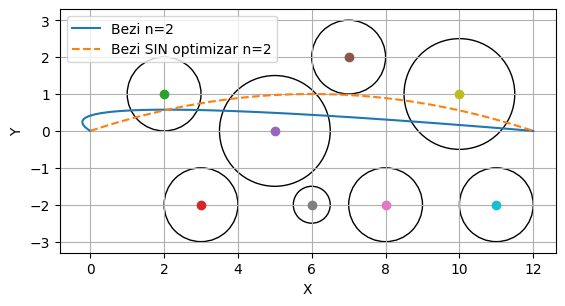

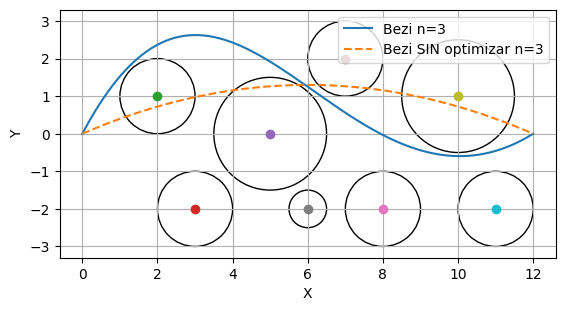

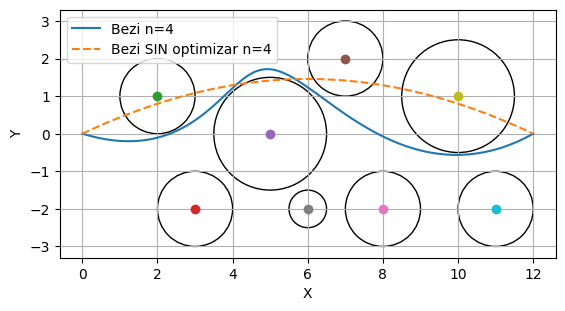

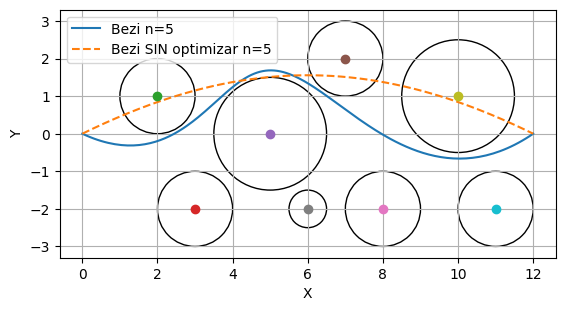

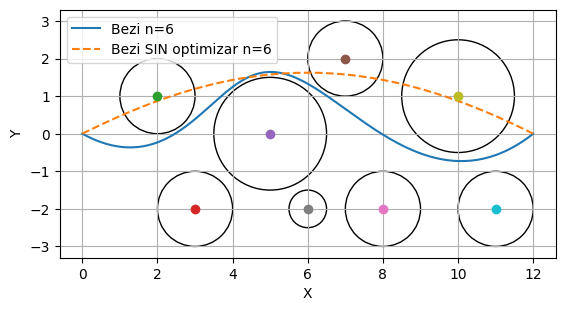

In [ ]:
plotear_lista_de_thetas(Lista_De_OptimizadosSmooth[0])

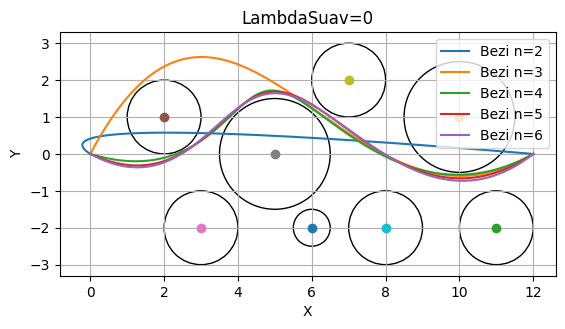

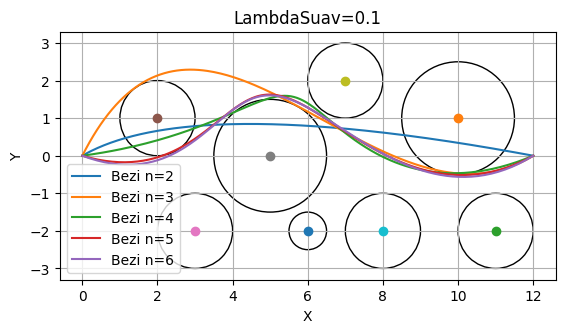

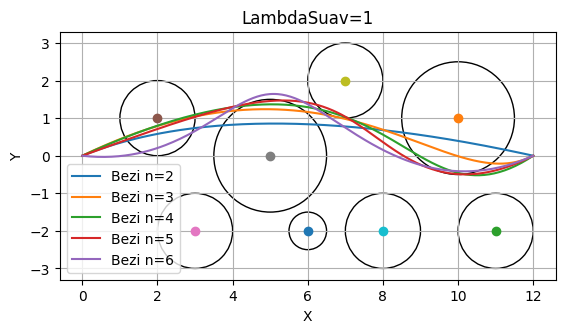

In [ ]:
for i in range(len(Lista_De_OptimizadosSmooth)):
  plotear_lista_en_un_plot(Lista_De_OptimizadosSmooth[i], "LambdaSuav="+str(lambdaSuavs[i]))